# TODO:
- [] write function to calculate

In [100]:
from src import ttl
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import cv2

In [111]:
base_data_path = '/Volumes/AhmedLab/princess/data/testers/timesynch_tests'
ttl_path = f'{base_data_path}/TSeries_20251218-514/TSeries_20251218-514_Cycle00001_VoltageRecording_001.csv'

bonsai_path  = f'{base_data_path}/202624_synchtest_time2026-02-04T16_02_22.csv'
video_path = f'{base_data_path}/202624_synchtest_side2026-02-04T16_02_22.avi'


## Pulling timestamps of frame start from VoltageRecording file

In [102]:
# load ttl file into dataframe
ttl_df = pd.read_csv(ttl_path)
print(ttl_df.columns)

Index(['Time(ms)', ' Input 1', ' Input 2', ' Input 3'], dtype='object')


In [126]:
# pull camera timestamps
cam_ttl = ttl_df[' Input 2']
time = ttl_df['Time(ms)']

# binarize signal
threshold = 3.2 # Volts
binarized_cam = []
for signal in cam_ttl:
    if signal > threshold:
        binarized_cam.append(1)
    else:
        binarized_cam.append(0)

# get frame starts by finding +1 changes
diffs = [0] + np.diff(binarized_cam)

timestamps = []
for i, val in enumerate(diffs):
    if val == 1:
        timestamps.append(time[i])

print(len(timestamps))

7774


In [137]:
# opto timestamps
# pull camera timestamps
opto_ttl = ttl_df[' Input 3']
# binarize signal
threshold = 3.2 # Volts
binarized_opto_ttl = []
for signal in opto_ttl:
    if signal > threshold:
        binarized_opto_ttl.append(1)
    else:
        binarized_opto_ttl.append(0)

# get frame starts by finding +1 changes
diffs = [0] + np.diff(binarized_opto_ttl)

timestamps_opto_ttl = []
for i, val in enumerate(diffs):
    if val == 1:
        timestamps_opto_ttl.append(time[i])

print(len(timestamps))

7774


ValueError: x and y must have same first dimension, but have shapes (1,) and (6047301,)

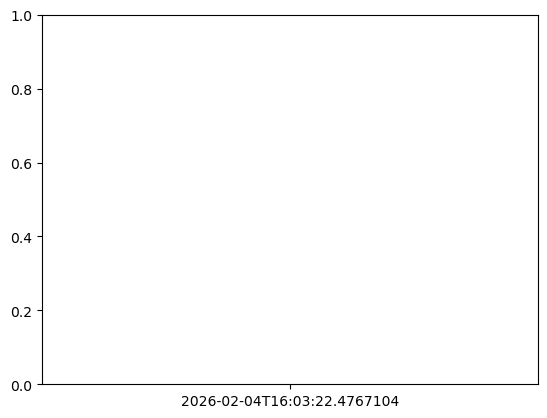

In [122]:
# plotting camera ttl with extracted frame starts

plt.plot(time, cam_ttl)
plt.vlines(timestamps, ymin=0, ymax=1, colors='r')
# plt.xlim(0,100)
plt.ylim(0,4)
plt.xlabel('Time(ms)')

## Pulling timestamps from Bonsai

In [105]:
bonsai_csv = pd.read_csv(bonsai_path, header=None)
bonsai_csv_array = bonsai_csv[0].to_numpy()

In [106]:
# loop over all times
bonsai_timestamps = []
for time in bonsai_csv_array:
    shortened_time = time[:-1] # datetime can only handle 6 digits in the milliseconds

    # convert string to datetime format
    dt_object = datetime.strptime(shortened_time, '%Y-%m-%dT%H:%M:%S.%f')
    bonsai_timestamps.append(dt_object)

start_time = bonsai_timestamps[0]

# to calculate time relative to first frame
relative_bonsai_timestamps = []
bonsai_timestamp_diffs = []
for i, ts in enumerate(bonsai_timestamps):
    relative_bonsai_timestamps.append((bonsai_timestamps[i]-start_time).total_seconds())
    bonsai_timestamp_diffs.append((bonsai_timestamps[i]-bonsai_timestamps[i-1]).total_seconds())
relative_bonsai_timestamps_ms = [x*1000 for x in relative_bonsai_timestamps]

(-1.0, 100.0)

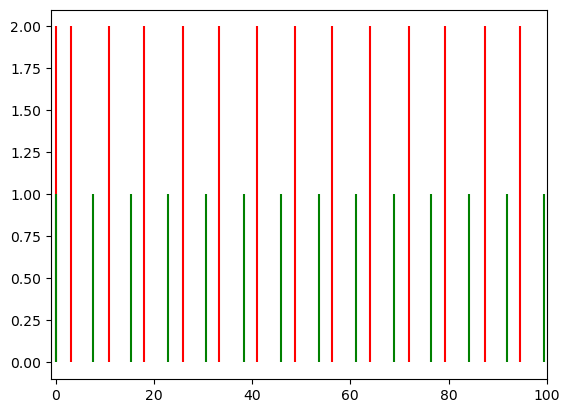

In [121]:
plt.vlines(relative_bonsai_timestamps_ms, ymin=0, ymax=2, colors='r')
plt.vlines(timestamps, ymin=0, ymax=1, colors='g')
plt.xlim(-1,100)

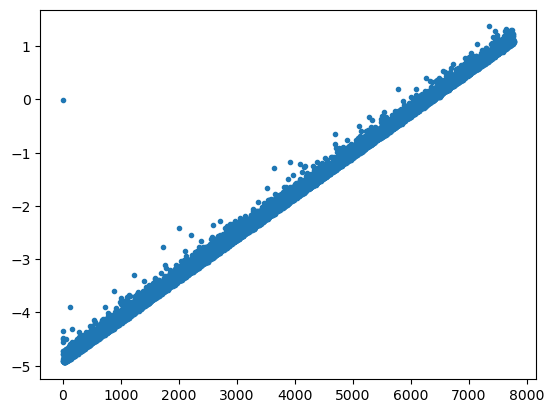

In [108]:
# time difference between sources
source_difference = [relative_bonsai_timestamps_ms[i] - timestamps[i] for i in range(len(relative_bonsai_timestamps_ms))]
plt.plot(source_difference, linestyle='None', marker='.')

## comparing opto times

In [109]:
(len(relative_bonsai_timestamps_ms))

7772

In [135]:
# binarize and find opto on times in bonsai
video = cv2.VideoCapture(video_path)
old_frame = None
average_brightness = []
while True:
    ret, frame = video.read()
    if ret == True:

        avg_pixel_val = np.mean(frame)
        average_brightness.append(avg_pixel_val)
    else:
        break

# binarize
threshold = 50
binarized_opto = []
for signal in average_brightness:
    if signal > threshold:
        binarized_opto.append(1)
    else:
        binarized_opto.append(0)
diffs = [0] + np.diff(binarized_opto)

opto_on_basler = []
for i, val in enumerate(diffs):
    if val == 1:
        opto_on_basler.append(relative_bonsai_timestamps_ms[i])

In [133]:
print(len(diffs), len(average_brightness))

7771 7772


In [138]:
timestamps_opto_ttl

[np.float64(500.0),
 np.float64(10500.26),
 np.float64(20500.52),
 np.float64(30500.78),
 np.float64(40501.04),
 np.float64(50501.3)]

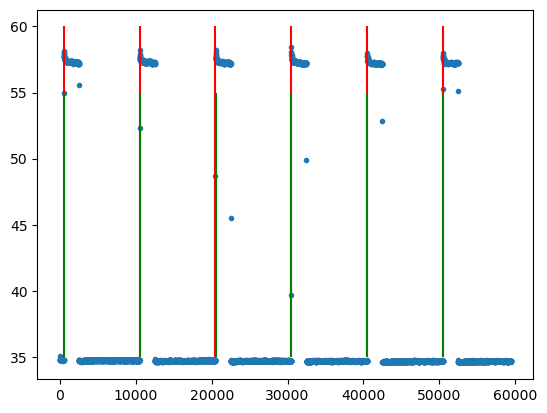

In [142]:
plt.plot(relative_bonsai_timestamps_ms, average_brightness, linestyle='None', marker='.')
plt.vlines(opto_on_basler,ymin=35, ymax=60, colors='r')
plt.vlines(timestamps_opto_ttl, ymin=35, ymax=55, colors='g')